In [2]:
# Running the example that is here: https://geometric-kernels.github.io/GeometricKernels/examples/frontends/GPyTorch.html


In [1]:
# Import a backend, we use torch in this example.
import gpytorch
import torch

# Import the geometric_kernels backend.
import geometric_kernels
import geometric_kernels.torch

# Import the Mesh space and the general-purpose MaternGeometricKernel
from geometric_kernels.spaces.mesh import Mesh
from geometric_kernels.kernels import MaternGeometricKernel

# The GPyTorch frontend of GeometricKernels
from geometric_kernels.frontends.gpytorch import GPyTorchGeometricKernel

# Sampling routines we will use to create a dummy dataset
from geometric_kernels.kernels import default_feature_map
from geometric_kernels.sampling import sampler
from geometric_kernels.utils.utils import make_deterministic

# Stuff
import numpy as np
import optax
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

import matplotlib.pyplot as plt

INFO (geometric_kernels): Numpy backend is enabled. To enable other backends, don't forget to `import geometric_kernels.*backend name*`.
INFO (geometric_kernels): We may be suppressing some logging of external libraries. To override the logging policy, call `logging.basicConfig`.
INFO (geometric_kernels): Torch backend enabled.


# Mesh Plotting Utils for plotly

In [2]:
def update_figure(fig):
    """Utility to clean up figure"""
    fig.update_layout(scene_aspectmode="cube")
    fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
    # fig.update_traces(showscale=False, hoverinfo="none")
    fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))

    fig.update_layout(plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)")
    fig.update_layout(
        scene=dict(
            xaxis=dict(showbackground=False, showticklabels=False, visible=False),
            yaxis=dict(showbackground=False, showticklabels=False, visible=False),
            zaxis=dict(showbackground=False, showticklabels=False, visible=False),
        )
    )
    return fig

def plot_mesh(mesh: Mesh, vertices_colors = None, **kwargs):
    plot = go.Mesh3d(
        x=mesh.vertices[:, 0],
        y=mesh.vertices[:, 1],
        z=mesh.vertices[:, 2],
        i=mesh.faces[:, 0],
        j=mesh.faces[:, 1],
        k=mesh.faces[:, 2],
        intensity=vertices_colors,
        **kwargs
    )
    return plot

# Defining a Space

In [3]:
mesh = Mesh.load_mesh(str(Path.cwd().parent / "Geometric Kernels_TeddyBear" / "teddy.obj"))
print("Number of vertices in the mesh:", mesh.num_vertices)

Number of vertices in the mesh: 1598


In [4]:
# Save mesh geometry
np.save('teddy_vertices.npy', mesh.vertices)
np.save('teddy_faces.npy', mesh.faces)

print("✅ Also saved:")
print(f"   📄 teddy_vertices.npy ({mesh.vertices.shape})")
print(f"   📄 teddy_faces.npy ({mesh.faces.shape})")

✅ Also saved:
   📄 teddy_vertices.npy ((1598, 3))
   📄 teddy_faces.npy ((3192, 3))


In [5]:
# Define the camera
camera = dict(
    up=dict(x=0, y=1, z=0),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=0, y=0.7, z=1.25)
)

plot = plot_mesh(mesh)
fig = go.Figure(plot)
update_figure(fig)
fig.update_layout(
    scene_camera=camera
)
fig.show()


# Get x and y data

In [6]:
num_data = 50
key = torch.Generator()
key.manual_seed(256)

xs_train = torch.randint(low=0, high=mesh.num_vertices, size=(num_data, 1), generator=key, dtype=torch.int64)
xs_test = torch.arange(mesh.num_vertices, dtype=torch.int64)[:, None]
# print("xs_train:", xs_train)
# print("xs_test:", xs_test)

In [7]:
xs_test.shape

torch.Size([1598, 1])

In [8]:
base_kernel = MaternGeometricKernel(mesh)

params = base_kernel.init_params()
params["lengthscale"] = torch.tensor([5.0], dtype=torch.float64)
params["nu"]  = torch.tensor([2.5], dtype=torch.float64)

feature_map = default_feature_map(kernel=base_kernel)
sample_paths = make_deterministic(sampler(feature_map), key)

_, ys_train  = sample_paths(xs_train, params)
key, ys_test = sample_paths(xs_test,  params)
ys_train = ys_train[:, 0]
ys_test = ys_test[:, 0]

assert(torch.allclose((ys_test[xs_train[:, 0]]), ys_train))

# Build the GP model

In [9]:
kernel = gpytorch.kernels.ScaleKernel(
            GPyTorchGeometricKernel(
                base_kernel,
                nu = params["nu"],
                lengthscale=params["lengthscale"],
                trainable_nu=False
            )
         )
kernel.outputscale = 1.0

In [10]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, kernel):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = kernel

    def forward(self, x):  # pylint: disable=arguments-differ
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.GaussianLikelihood(
    noise_constraint=gpytorch.constraints.GreaterThan(1e-6)
)
likelihood.noise = torch.tensor(1e-4)

model = ExactGPModel(xs_train, ys_train, likelihood, kernel)

# use float64:
model.double()
likelihood.double()

print("Initial model:")
print("kernel.base_kernel.nu =", model.covar_module.base_kernel.nu)
print("kernel.base_kernel.lengthscale =", model.covar_module.base_kernel.lengthscale)
print("kernel.outputscale =", model.covar_module.outputscale)
print("likelihood.obs_noise =", model.likelihood.noise)
print("")

# Note: this is divided by the number of data points, hence may appear
# quite different from the marginal log likelihoods of other frontends.
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

print("Initial negative log marginal likelihood:", -mll(model(xs_train), ys_train).detach().numpy())

Initial model:
kernel.base_kernel.nu = tensor([2.5000], dtype=torch.float64)
kernel.base_kernel.lengthscale = tensor([[5.0000]], dtype=torch.float64, grad_fn=<SoftplusBackward0>)
kernel.outputscale = tensor(1.0000, dtype=torch.float64, grad_fn=<SoftplusBackward0>)
likelihood.obs_noise = tensor([0.0001], dtype=torch.float64, grad_fn=<AddBackward0>)

Initial negative log marginal likelihood: 2791.274757318807


# Train the Model, Optimizing hyperparameters

In [11]:
# Put the model into training mode
model.train()
likelihood.train()

# Use the Adam optimizer, with a set learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Set the number of training iterations
n_iter = 100

print("Starting training...")
for i in range(n_iter):
    # Set the gradients from previous iteration to zero
    optimizer.zero_grad()
    # Output from model
    output = model(xs_train)
    # Compute loss and backprop gradients
    loss = -mll(output, ys_train)
    loss.backward()
    if i == 0 or (i+1) % 10 == 0:
        print("Iter %d/%d - Loss: %.5f" % (i + 1, n_iter, loss.item()))
    optimizer.step()

print("")
print("Final model:")
print("kernel.base_kernel.nu =", model.covar_module.base_kernel.nu)
print("kernel.base_kernel.lengthscale =", model.covar_module.base_kernel.lengthscale)
print("kernel.outputscale =", model.covar_module.outputscale)
print("likelihood.obs_noise =", model.likelihood.noise)
print("")

print("Final negative log marginal likelihood:", -mll(model(xs_train), ys_train).detach().numpy())

Starting training...
Iter 1/100 - Loss: 2791.27476
Iter 10/100 - Loss: 1535.34724
Iter 20/100 - Loss: 1043.31024
Iter 30/100 - Loss: 836.53436
Iter 40/100 - Loss: 722.02847
Iter 50/100 - Loss: 647.35907
Iter 60/100 - Loss: 594.15468
Iter 70/100 - Loss: 553.55825
Iter 80/100 - Loss: 520.69403
Iter 90/100 - Loss: 492.80837
Iter 100/100 - Loss: 468.05370

Final model:
kernel.base_kernel.nu = tensor([2.5000], dtype=torch.float64)
kernel.base_kernel.lengthscale = tensor([[3.4650]], dtype=torch.float64, grad_fn=<SoftplusBackward0>)
kernel.outputscale = tensor(5.1119, dtype=torch.float64, grad_fn=<SoftplusBackward0>)
likelihood.obs_noise = tensor([0.0176], dtype=torch.float64, grad_fn=<AddBackward0>)

Final negative log marginal likelihood: 465.67587223499584


In [12]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

likelihood.noise_covar.raw_noise True
covar_module.raw_outputscale True
covar_module.base_kernel.raw_lengthscale True


# Draw Predictions and Evaluation Model

In [13]:
# switch model to prediction mode
model.eval()

# print(xs_train.shape, xs_test.shape, ys_train.shape, ys_test.shape)

# predict mean and variance
latent_dist = model(xs_test)
posterior_mean = torch.reshape(latent_dist.mean, ys_test.shape).detach().numpy()
posterior_std = torch.reshape(latent_dist.stddev, ys_test.shape).detach().numpy()

# predict sample
sample = latent_dist.sample(sample_shape=torch.Size([1])).detach().numpy()[0, :]

In [14]:
# Mark training data
training_data_coords = mesh.vertices[xs_train[:, 0]]

training_data_plot  = go.Scatter3d(
    x=np.array(training_data_coords[:, 0]),
    y=np.array(training_data_coords[:, 1]),
    z=np.array(training_data_coords[:, 2]),
    mode = "markers",
    marker_color = "red",
    name="",
    showlegend=False,
)

# Various plots as plotly traces
ground_truth_plot   = plot_mesh(mesh, vertices_colors=ys_test, colorscale="Viridis",
                                colorbar=dict(
                                x=0,
                                y=0.75,
                                xanchor="center",
                                yanchor="middle",
                                len=0.4,
                                thicknessmode="fraction",
                                thickness=0.01)
                               )
sample_plot         = plot_mesh(mesh, vertices_colors=sample, colorscale="Viridis",
                                colorbar=dict(
                                x=1.0,
                                y=0.75,
                                xanchor="center",
                                yanchor="middle",
                                len=0.4,
                                thicknessmode="fraction",
                                thickness=0.01)
                               )

posterior_mean_plot = plot_mesh(mesh, vertices_colors=posterior_mean, colorscale="Viridis",
                                colorbar=dict(
                                x=0.0,
                                y=0.25,
                                xanchor="center",
                                yanchor="middle",
                                len=0.4,
                                thicknessmode="fraction",
                                thickness=0.01)
                               )

posterior_std_plot  = plot_mesh(mesh, vertices_colors=posterior_std, colorscale="Plasma",
                                colorbar=dict(
                                x=1.0,
                                y=0.25,
                                xanchor="center",
                                yanchor="middle",
                                len=0.4,
                                thicknessmode="fraction",
                                thickness=0.01)
                               )

# Setting up the layout
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}],
           [{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=(r"Ground Truth",
                    r"Posterior Sample",
                    r"Prediction",
                    r"Posterior Standard Deviation"),
    vertical_spacing=0.1)

# Adding the traces
fig.add_trace(ground_truth_plot,   row=1, col=1)

fig.add_trace(training_data_plot,  row=1, col=2)
fig.add_trace(sample_plot,         row=1, col=2)

fig.add_trace(training_data_plot,  row=2, col=1)
fig.add_trace(posterior_mean_plot,  row=2, col=1)

fig.add_trace(training_data_plot,  row=2, col=2)
fig.add_trace(posterior_std_plot, row=2, col=2)


fig = update_figure(fig)

fig.layout.scene1.camera = camera
fig.layout.scene2.camera = camera
fig.layout.scene3.camera = camera
fig.layout.scene4.camera = camera


fig.update_layout(
    margin={"t": 50},
)

fig.show(width=1000, height=800)

In [15]:
ys_test.shape

torch.Size([1598])

/tmp/ipykernel_881307/3821902685.py:10: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



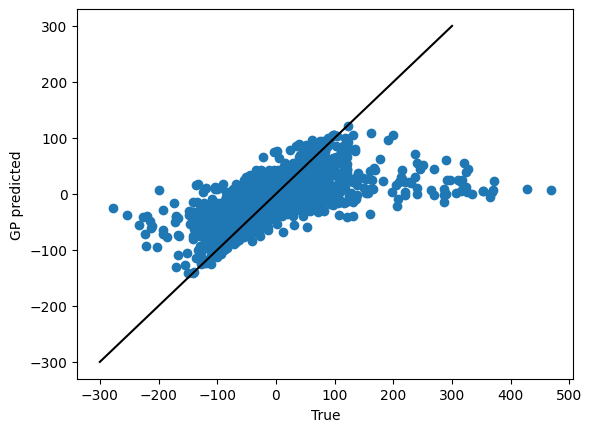

RMSE: 69.27761821230462


In [16]:
# Convert to numpy first
ys_test_np = ys_test.detach().cpu().numpy()
posterior_mean_np = posterior_mean
my_line = np.linspace(-300,300,10)

plt.scatter(ys_test_np, posterior_mean_np)
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

rmse = np.sqrt(np.mean((ys_test_np - posterior_mean_np)**2))
print(f"RMSE: {rmse}")

In [17]:
from scipy.stats import norm

def _crps_s(x, mu, sigma):
        res = abs(sigma * ((1. / np.sqrt(np.pi))
                           - 2. * norm.pdf((x - mu) / sigma)
                           - (((x - mu) / sigma) * (2. * norm.cdf((x - mu) / sigma) - 1.))))
        return np.mean(res), np.sqrt(np.var(res))

def crps(mean, sigma, y_test):
    """
    This function calculates the continuous rank probability score.

    Parameters
    ----------
    x_test : np.ndarray
        A numpy array of shape (V x D), interpreted as  an array of input point positions.
    y_test : np.ndarray
        A numpy array of shape (V x No) in the multi-output case. These are the y data to compare against.

    Return
    ------
    CRPS, standard dev. of CRPS : (float, float)
    """
    
    assert mean.shape == sigma.shape == y_test.shape, (mean.shape, sigma.shape, y_test.shape)
    r = _crps_s(y_test, mean, sigma)
    return r
    

latent_dist = model(xs_test)
posterior_mean = torch.reshape(latent_dist.mean, ys_test.shape).detach().numpy()
posterior_std = torch.reshape(latent_dist.stddev, ys_test.shape).detach().numpy()

my_crsp = crps(posterior_mean, posterior_std, ys_test_np)
print("Mean CRPS: ", my_crsp[0])
print("std CRPS: ", my_crsp[1])

print(posterior_mean[0], posterior_std[0])

Mean CRPS:  41.34773619272833
std CRPS:  54.57714151652862
76.86167799886934 2.616302692273969


In [18]:
def picp(mu, sigma, y_true, interval=0.95):
        """
        Computes the Prediction Interval Coverage Probability (PICP)
        for a Gaussian Process posterior.

        Parameters
        ----------
        x_test : array-like, shape (N,dim)
        y_true : array-like, shape (N,)
            True values of the target variable.
        interval : float, optional
            Confidence interval (default 0.95 for 95% intervals).

        Returns
        -------
        picp : float
            Prediction Interval Coverage Probability
        lower_bounds : ndarray
            Lower bounds of prediction intervals
        upper_bounds : ndarray
            Upper bounds of prediction intervals
        """

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp

# The standard deviation should include the noise here, that is why we are using the likelihood
likelihood.eval()

predictive_dist = likelihood(model(xs_test))
posterior_mean = torch.reshape(predictive_dist.mean, ys_test.shape).detach().numpy()
posterior_std = torch.reshape(predictive_dist.stddev, ys_test.shape).detach().numpy()

my_picp = picp(posterior_mean, posterior_std, ys_test_np)
my_picp

np.float64(0.07884856070087609)

(array([246., 294., 375., 413., 130.,  45.,  61.,  22.,   6.,   6.]),
 array([0.16464728, 0.70880771, 1.25296815, 1.79712858, 2.34128902,
        2.88544945, 3.42960989, 3.97377032, 4.51793076, 5.06209119,
        5.60625163]),
 <BarContainer object of 10 artists>)

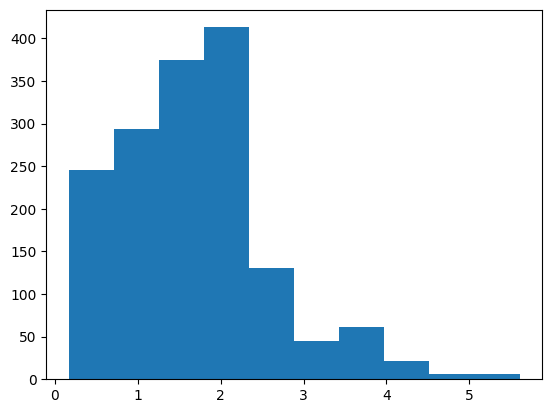

In [20]:
plt.hist(posterior_std)

In [22]:
print(f"noise       = {model.likelihood.noise.item():.6f}")
print(f"outputscale = {model.covar_module.outputscale.item():.6f}")
print(f"lengthscale = {model.covar_module.base_kernel.lengthscale.item():.6f}")

noise       = 0.017634
outputscale = 5.111906
lengthscale = 3.464990


# Compute the Geodesic Distances

## Heat Method, an approximation

In [33]:
# import numpy as np
# import torch
# import potpourri3d as pp3d
# from pathlib import Path

# print("=" * 70)
# print("COMPUTING GEODESIC DISTANCES AND Y VALUES FOR TEDDY MESH")
# print("=" * 70)

# # ============================================================================
# # 1. LOAD MESH
# # ============================================================================
# print("\n📁 Loading mesh...")
# mesh = Mesh.load_mesh(str(Path.cwd().parent / "Geometric Kernels" / "teddy.obj"))
# n_vertices = mesh.num_vertices

# print(f"✅ Loaded mesh: {n_vertices} vertices")
# print(f"   Memory needed: ~{n_vertices**2 * 4 / 1e6:.1f} MB")

# # ============================================================================
# # 2. COMPUTE GEODESIC DISTANCES (WITH SYMMETRY ENFORCED)
# # ============================================================================
# print(f"\n🔧 Computing geodesic distance matrix...")
# solver = pp3d.MeshHeatMethodDistanceSolver(mesh.vertices, mesh.faces)

# geodesic_distances_full = np.zeros((n_vertices, n_vertices), dtype=np.float32)

# for i in range(n_vertices):
#     distances = solver.compute_distance(i)
    
#     # Enforce symmetry immediately
#     geodesic_distances_full[i, :] = distances
#     geodesic_distances_full[:, i] = distances
    
#     if (i + 1) % 100 == 0:
#         print(f"  Progress: {i+1}/{n_vertices} ({100*(i+1)/n_vertices:.1f}%)")

# # Clip any tiny negative values (numerical noise)
# geodesic_distances_full = np.maximum(geodesic_distances_full, 0)

# # Verify
# print(f"\n✅ Geodesic distance matrix computed!")
# print(f"   Shape: {geodesic_distances_full.shape}")
# print(f"   Min: {geodesic_distances_full[np.triu_indices_from(geodesic_distances_full, k=1)].min():.6f}")
# print(f"   Max: {geodesic_distances_full.max():.3f}")
# print(f"   Mean: {geodesic_distances_full.mean():.3f}")
# print(f"   Symmetric: {np.allclose(geodesic_distances_full, geodesic_distances_full.T)}")

# # ============================================================================
# # 3. GENERATE Y VALUES FOR ALL VERTICES
# # ============================================================================
# print(f"\n🔧 Generating y values for all vertices...")

# # Setup kernel and parameters
# base_kernel = MaternGeometricKernel(mesh)
# params = base_kernel.init_params()
# params["lengthscale"] = torch.tensor([5.0], dtype=torch.float64)
# params["nu"] = torch.tensor([2.5], dtype=torch.float64)

# # Generate for all vertices
# xs_all = torch.arange(n_vertices, dtype=torch.int64)[:, None]

# key = torch.Generator()
# key.manual_seed(1234)

# feature_map = default_feature_map(kernel=base_kernel)
# sample_paths = make_deterministic(sampler(feature_map), key)

# _, ys_all = sample_paths(xs_all, params)
# ys_all = ys_all[:, 0].cpu().numpy()

# print(f"✅ Y values generated!")
# print(f"   Shape: {ys_all.shape}")
# print(f"   Min: {ys_all.min():.3f}")
# print(f"   Max: {ys_all.max():.3f}")
# print(f"   Mean: {ys_all.mean():.3f}")

# # ============================================================================
# # 4. SAVE EVERYTHING
# # ============================================================================
# print(f"\n💾 Saving files...")

# np.save('teddy_geodesic_distances.npy', geodesic_distances_full)
# np.save('teddy_y_values.npy', ys_all)

# print(f"\n✅ COMPLETE! Saved:")
# print(f"   📄 teddy_geodesic_distances.npy ({geodesic_distances_full.shape})")
# print(f"   📄 teddy_y_values.npy ({ys_all.shape})")
# print("=" * 70)

COMPUTING GEODESIC DISTANCES AND Y VALUES FOR TEDDY MESH

📁 Loading mesh...
✅ Loaded mesh: 1598 vertices
   Memory needed: ~10.2 MB

🔧 Computing geodesic distance matrix...
  Progress: 100/1598 (6.3%)
  Progress: 200/1598 (12.5%)
  Progress: 300/1598 (18.8%)
  Progress: 400/1598 (25.0%)
  Progress: 500/1598 (31.3%)
  Progress: 600/1598 (37.5%)
  Progress: 700/1598 (43.8%)
  Progress: 800/1598 (50.1%)
  Progress: 900/1598 (56.3%)
  Progress: 1000/1598 (62.6%)
  Progress: 1100/1598 (68.8%)
  Progress: 1200/1598 (75.1%)
  Progress: 1300/1598 (81.4%)
  Progress: 1400/1598 (87.6%)
  Progress: 1500/1598 (93.9%)

✅ Geodesic distance matrix computed!
   Shape: (1598, 1598)
   Min: 0.000000
   Max: 53.566
   Mean: 22.881
   Symmetric: True

🔧 Generating y values for all vertices...
✅ Y values generated!
   Shape: (1598,)
   Min: -359.610
   Max: 361.440
   Mean: 1.476

💾 Saving files...

✅ COMPLETE! Saved:
   📄 teddy_geodesic_distances.npy ((1598, 1598))
   📄 teddy_y_values.npy ((1598,))


# Exact Method

In [3]:
import numpy as np
import networkx as nx
from pathlib import Path

print("🚀 Computing Geodesic Distance Matrix for Teddy Mesh")
print("=" * 70)

# ============================================================================
# 1. LOAD MESH
# ============================================================================
mesh = Mesh.load_mesh(str(Path.cwd().parent / "Geometric Kernels_TeddyBear" / "teddy.obj"))
vertices   = mesh.vertices
faces      = mesh.faces
n_vertices = mesh.num_vertices

print(f"✅ Mesh loaded: {n_vertices:,} vertices, {len(faces):,} faces")
print(f"   Memory required: {n_vertices**2 * 4 / 1e6:.2f} MB")

# ============================================================================
# 2. BUILD MESH GRAPH
# ============================================================================
def build_mesh_graph(vertices, faces):
    G = nx.Graph()
    G.add_nodes_from(range(len(vertices)))
    for face in faces:
        face = list(face)
        n = len(face)
        for k in range(n):
            u = face[k]
            v = face[(k + 1) % n]
            if u != v and not G.has_edge(u, v):
                weight = float(np.linalg.norm(vertices[u] - vertices[v]))
                G.add_edge(u, v, weight=weight)
    return G

print("\n🔧 Constructing mesh graph...")
mesh_graph = build_mesh_graph(vertices, faces)
print(f"✅ Graph: {mesh_graph.number_of_nodes():,} nodes, "
      f"{mesh_graph.number_of_edges():,} edges")
print(f"   Connected: {nx.is_connected(mesh_graph)}")

# ============================================================================
# 3. COMPUTE FULL GEODESIC DISTANCE MATRIX
# ============================================================================
print("\n🔧 Computing geodesic distances...")

geo_dist = np.full((n_vertices, n_vertices), np.inf, dtype=np.float32)
np.fill_diagonal(geo_dist, 0.0)

for source in range(n_vertices):
    dists = nx.shortest_path_length(mesh_graph, source=source, weight='weight')
    for target, d in dists.items():
        if target >= source:                    # upper triangle
            geo_dist[source, target] = d
            geo_dist[target, source] = d        # mirror immediately

    if (source + 1) % 100 == 0:
        print(f"  Progress: {source+1}/{n_vertices} ({100*(source+1)/n_vertices:.1f}%)")

# ============================================================================
# 4. VERIFY AND SAVE
# ============================================================================
print(f"\n✅ Geodesic distance matrix computed!")
print(f"   Shape:     {geo_dist.shape}")
print(f"   Min (off-diagonal): {geo_dist[geo_dist > 0].min():.6f}")
print(f"   Max:       {geo_dist.max():.4f}")
print(f"   Mean:      {geo_dist.mean():.4f}")
print(f"   Symmetric: {np.allclose(geo_dist, geo_dist.T)}")
print(f"   Any inf:   {np.any(np.isinf(geo_dist))}")

np.save('teddy_exact_geodesic_distances_graph.npy', geo_dist)
print(f"\n💾 Saved: teddy_exact_geodesic_distances_graph.npy")
print("=" * 70)

🚀 Computing Geodesic Distance Matrix for Teddy Mesh
✅ Mesh loaded: 1,598 vertices, 3,192 faces
   Memory required: 10.21 MB

🔧 Constructing mesh graph...
✅ Graph: 1,598 nodes, 4,788 edges
   Connected: True

🔧 Computing geodesic distances...
  Progress: 100/1598 (6.3%)
  Progress: 200/1598 (12.5%)
  Progress: 300/1598 (18.8%)
  Progress: 400/1598 (25.0%)
  Progress: 500/1598 (31.3%)
  Progress: 600/1598 (37.5%)
  Progress: 700/1598 (43.8%)
  Progress: 800/1598 (50.1%)
  Progress: 900/1598 (56.3%)
  Progress: 1000/1598 (62.6%)
  Progress: 1100/1598 (68.8%)
  Progress: 1200/1598 (75.1%)
  Progress: 1300/1598 (81.4%)
  Progress: 1400/1598 (87.6%)
  Progress: 1500/1598 (93.9%)

✅ Geodesic distance matrix computed!
   Shape:     (1598, 1598)
   Min (off-diagonal): 0.003835
   Max:       56.9255
   Mean:      24.3404
   Symmetric: True
   Any inf:   False

💾 Saved: teddy_geodesic_distances_graph.npy


In [5]:
# Validating the exact geodesic distance

import numpy as np

print("=" * 70)
print("VALIDATING EXACT GEODESIC DISTANCE MATRIX")
print("=" * 70)

geo = np.load('teddy_exact_geodesic_distances_graph.npy')
n = geo.shape[0]

print(f"\nShape: {geo.shape}")

# ============================================================================
# 1. BASIC PROPERTIES
# ============================================================================
print("\n--- Basic Properties ---")

# Zero diagonal
diag_ok = np.allclose(np.diag(geo), 0.0)
print(f"Zero diagonal:     {'✅' if diag_ok else '❌'}  (max diag value: {np.diag(geo).max():.6f})")

# Non-negativity
nonneg_ok = np.all(geo >= 0)
print(f"Non-negative:      {'✅' if nonneg_ok else '❌'}  (min value: {geo.min():.6f})")

# No infinities or NaNs
no_inf = not np.any(np.isinf(geo))
no_nan = not np.any(np.isnan(geo))
print(f"No infinities:     {'✅' if no_inf else '❌'}  (inf count: {np.isinf(geo).sum()})")
print(f"No NaNs:           {'✅' if no_nan else '❌'}  (nan count: {np.isnan(geo).sum()})")

# Symmetry
sym_ok = np.allclose(geo, geo.T, atol=1e-5)
max_asym = np.abs(geo - geo.T).max()
print(f"Symmetric:         {'✅' if sym_ok else '❌'}  (max asymmetry: {max_asym:.2e})")

# ============================================================================
# 2. TRIANGLE INEQUALITY (sampled - checking all triples is O(n^3))
# ============================================================================
print("\n--- Triangle Inequality (sampled) ---")

rng = np.random.default_rng(42)
sample_idx = rng.choice(n, size=200, replace=False)
geo_sample = geo[np.ix_(sample_idx, sample_idx)]

i_idx, j_idx, k_idx = np.meshgrid(np.arange(len(sample_idx)),
                                    np.arange(len(sample_idx)),
                                    np.arange(len(sample_idx)), indexing='ij')

lhs = geo_sample[i_idx, j_idx]
rhs = geo_sample[i_idx, k_idx] + geo_sample[k_idx, j_idx]

violations = np.sum(lhs > rhs + 1e-5)
total = len(sample_idx) ** 3
print(f"Violations:        {violations} / {total:,} triples")
print(f"Triangle ineq:     {'✅' if violations == 0 else '❌'}")

# ============================================================================
# 3. DISTRIBUTION STATS
# ============================================================================
print("\n--- Distance Distribution ---")
off_diag = geo[~np.eye(n, dtype=bool)]
print(f"Min (off-diag):    {off_diag.min():.6f}")
print(f"Max:               {off_diag.max():.6f}")
print(f"Mean:              {off_diag.mean():.6f}")
print(f"Median:            {np.median(off_diag):.6f}")
print(f"Std:               {off_diag.std():.6f}")

# ============================================================================
# 4. CONNECTIVITY - any unreachable pairs?
# ============================================================================
print("\n--- Connectivity ---")
unreachable = np.sum(np.isinf(geo) | (geo == 0) & ~np.eye(n, dtype=bool))
print(f"Unreachable pairs: {unreachable}")
print(f"Fully connected:   {'✅' if unreachable == 0 else '❌'}")

print("\n" + "=" * 70)
all_ok = diag_ok and nonneg_ok and no_inf and no_nan and sym_ok and violations == 0
print(f"OVERALL VALID: {'✅ YES' if all_ok else '❌ NO'}")
print("=" * 70)

VALIDATING EXACT GEODESIC DISTANCE MATRIX

Shape: (1598, 1598)

--- Basic Properties ---
Zero diagonal:     ✅  (max diag value: 0.000000)
Non-negative:      ✅  (min value: 0.000000)
No infinities:     ✅  (inf count: 0)
No NaNs:           ✅  (nan count: 0)
Symmetric:         ✅  (max asymmetry: 0.00e+00)

--- Triangle Inequality (sampled) ---
Violations:        0 / 8,000,000 triples
Triangle ineq:     ✅

--- Distance Distribution ---
Min (off-diag):    0.003835
Max:               56.925507
Mean:              24.355646
Median:            24.355429
Std:               10.901197

--- Connectivity ---
Unreachable pairs: 0
Fully connected:   ✅

OVERALL VALID: ✅ YES


COMPARING EXACT vs HEAT METHOD GEODESIC DISTANCES

--- Global Stats (off-diagonal) ---
Metric                           Exact         Heat
--------------------------------------------------
Min                             0.0038       0.0000
Max                            56.9255      53.5664
Mean                           24.3556      22.8948
Median                         24.3554      22.8810
Std                            10.9012      10.4159

--- Error Analysis ---
Mean Absolute Error:       1.485217
Median Absolute Error:     1.346187
Max Absolute Error:        7.022909
Mean Relative Error:       6.5622%
Median Relative Error:     6.0250%
Max Relative Error:        100.0000%
Correlation (Pearson r):   0.99677988


/tmp/ipykernel_1751484/2521930506.py:104: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_1751484/2521930506.py:105: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('geodesic_comparison.png', dpi=150, bbox_inches='tight')
/global/homes/m/malghal/.conda/envs/geometricKernels/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


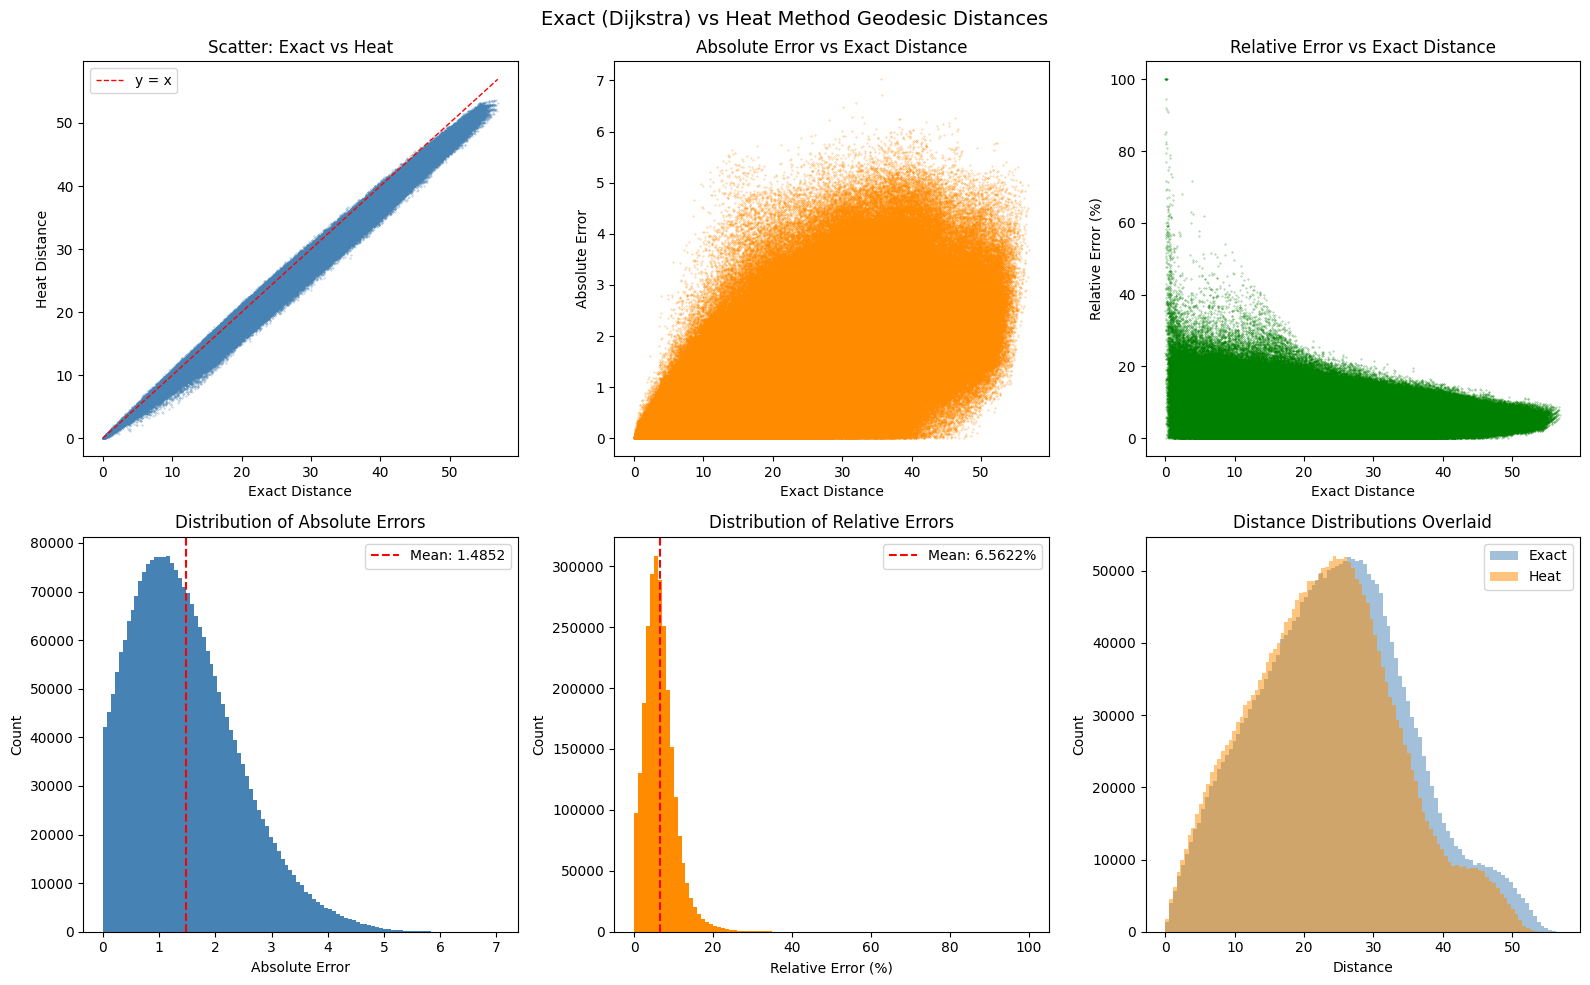


💾 Saved: geodesic_comparison.png


In [7]:
# Comparing the exact and approximated Geodesic distance

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("COMPARING EXACT vs HEAT METHOD GEODESIC DISTANCES")
print("=" * 70)

exact = np.load('teddy_exact_geodesic_distances_graph.npy')
heat  = np.load('teddy_geodesic_distances.npy')
n     = exact.shape[0]

# Off-diagonal mask
mask = ~np.eye(n, dtype=bool)
exact_od = exact[mask]
heat_od  = heat[mask]

# ============================================================================
# 1. GLOBAL STATISTICS
# ============================================================================
print("\n--- Global Stats (off-diagonal) ---")
print(f"{'Metric':<25} {'Exact':>12} {'Heat':>12}")
print("-" * 50)
print(f"{'Min':<25} {exact_od.min():>12.4f} {heat_od.min():>12.4f}")
print(f"{'Max':<25} {exact_od.max():>12.4f} {heat_od.max():>12.4f}")
print(f"{'Mean':<25} {exact_od.mean():>12.4f} {heat_od.mean():>12.4f}")
print(f"{'Median':<25} {np.median(exact_od):>12.4f} {np.median(heat_od):>12.4f}")
print(f"{'Std':<25} {exact_od.std():>12.4f} {heat_od.std():>12.4f}")

# ============================================================================
# 2. ERROR ANALYSIS
# ============================================================================
print("\n--- Error Analysis ---")
diff     = heat_od - exact_od
abs_diff = np.abs(diff)
rel_diff = abs_diff / (exact_od + 1e-10)

print(f"Mean Absolute Error:       {abs_diff.mean():.6f}")
print(f"Median Absolute Error:     {np.median(abs_diff):.6f}")
print(f"Max Absolute Error:        {abs_diff.max():.6f}")
print(f"Mean Relative Error:       {rel_diff.mean()*100:.4f}%")
print(f"Median Relative Error:     {np.median(rel_diff)*100:.4f}%")
print(f"Max Relative Error:        {rel_diff.max()*100:.4f}%")
print(f"Correlation (Pearson r):   {np.corrcoef(exact_od, heat_od)[0,1]:.8f}")

# ============================================================================
# 3. PLOTS
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exact (Dijkstra) vs Heat Method Geodesic Distances", fontsize=14)

# --- Scatter: exact vs heat ---
ax = axes[0, 0]
ax.scatter(exact_od, heat_od, s=0.1, alpha=0.3, color='steelblue')
lims = [0, max(exact_od.max(), heat_od.max())]
ax.plot(lims, lims, 'r--', lw=1, label='y = x')
ax.set_xlabel("Exact Distance")
ax.set_ylabel("Heat Distance")
ax.set_title("Scatter: Exact vs Heat")
ax.legend()

# --- Absolute error vs exact distance ---
ax = axes[0, 1]
ax.scatter(exact_od, abs_diff, s=0.1, alpha=0.3, color='darkorange')
ax.set_xlabel("Exact Distance")
ax.set_ylabel("Absolute Error")
ax.set_title("Absolute Error vs Exact Distance")

# --- Relative error vs exact distance ---
ax = axes[0, 2]
ax.scatter(exact_od, rel_diff * 100, s=0.1, alpha=0.3, color='green')
ax.set_xlabel("Exact Distance")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Relative Error vs Exact Distance")

# --- Histogram of absolute errors ---
ax = axes[1, 0]
ax.hist(abs_diff, bins=100, color='steelblue', edgecolor='none')
ax.set_xlabel("Absolute Error")
ax.set_ylabel("Count")
ax.set_title("Distribution of Absolute Errors")
ax.axvline(abs_diff.mean(), color='r', linestyle='--', label=f'Mean: {abs_diff.mean():.4f}')
ax.legend()

# --- Histogram of relative errors ---
ax = axes[1, 1]
ax.hist(rel_diff * 100, bins=100, color='darkorange', edgecolor='none')
ax.set_xlabel("Relative Error (%)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Relative Errors")
ax.axvline(rel_diff.mean()*100, color='r', linestyle='--', label=f'Mean: {rel_diff.mean()*100:.4f}%')
ax.legend()

# --- Distribution of both matrices overlaid ---
ax = axes[1, 2]
ax.hist(exact_od, bins=100, alpha=0.5, color='steelblue', edgecolor='none', label='Exact')
ax.hist(heat_od,  bins=100, alpha=0.5, color='darkorange', edgecolor='none', label='Heat')
ax.set_xlabel("Distance")
ax.set_ylabel("Count")
ax.set_title("Distance Distributions Overlaid")
ax.legend()

plt.tight_layout()
plt.savefig('geodesic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: geodesic_comparison.png")
print("=" * 70)

# Running Multiple examples for comparison

In [1]:
import json 
import os
import torch
import numpy as np
from scipy.stats import norm
import time 

import gpytorch
import geometric_kernels.torch  # <-- add this line
from geometric_kernels.spaces import Mesh
from geometric_kernels.kernels import MaternGeometricKernel
from geometric_kernels.frontends.gpytorch import GPyTorchGeometricKernel
import traceback


# Load numpy arrays and convert to torch tensors
vertices = np.load('teddy_vertices.npy').astype(np.float64)
faces = np.load('teddy_faces.npy').astype(np.int32)
mesh = Mesh(vertices, faces)
y_values_np = np.load('teddy_y_values.npy')
y_values = torch.tensor(y_values_np, dtype=torch.float64)  # Convert to torch

# Build mesh and kernel — must be before function definitions
#mesh = Mesh(vertices, faces)
base_kernel = MaternGeometricKernel(mesh)
params = base_kernel.init_params()
params["lengthscale"] = np.array([5.0])
params["nu"] = np.array([2.5])

def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    # Convert to torch tensor with proper shape
    x_test = torch.tensor(test_indices, dtype=torch.int64)[:, None]  # Shape: (n, 1)
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    # Convert to torch tensor with proper shape
    x_train = torch.tensor(indices_train, dtype=torch.int64)[:, None]  # Shape: (n, 1)
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed

def rmse_manual(y_true, y_pred):
    """Calculate RMSE - handles both torch tensors and numpy arrays"""
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.detach().numpy()
    
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def _crps_s(x, mu, sigma):
        res = abs(sigma * ((1. / np.sqrt(np.pi))
                           - 2. * norm.pdf((x - mu) / sigma)
                           - (((x - mu) / sigma) * (2. * norm.cdf((x - mu) / sigma) - 1.))))
        return np.mean(res), np.sqrt(np.var(res))
def crps(mean, sigma, y_test):
    r = _crps_s(y_test, mean, sigma)
    return r


def picp(mu, sigma, y_true, interval=0.95):
        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
    
def train_gp_model_rmse_crps_picp(x_train, y_train, x_test, y_test):

    kernel = gpytorch.kernels.ScaleKernel(GPyTorchGeometricKernel(
                            base_kernel,
                            nu=torch.tensor(params["nu"], dtype=torch.float64),          # convert here
                            lengthscale=torch.tensor(params["lengthscale"], dtype=torch.float64),  # convert here
                            trainable_nu=False
                        )
                    )
    kernel.outputscale = 1.0

    class ExactGPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood, kernel):
            super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ZeroMean()
            self.covar_module = kernel
    
        def forward(self, x):  # pylint: disable=arguments-differ
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
    likelihood = gpytorch.likelihoods.GaussianLikelihood(
        noise_constraint=gpytorch.constraints.GreaterThan(1e-6)
    )
    likelihood.noise = torch.tensor(1e-4)
    
    model = ExactGPModel(x_train, y_train, likelihood, kernel)
    
    # use float64:
    model.double()
    likelihood.double()
    
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    # Put the model into training mode
    model.train()
    likelihood.train()
    
    # Use the Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    
    # Set the number of training iterations
    n_iter = 100
    
    #print("Starting training...")
    for i in range(n_iter):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()
    
    # switch model to prediction mode
    model.eval()
    likelihood.eval()
    
    # # predict mean
    # with torch.no_grad():
    #     latent_dist_test = model(x_test)
    #     mean_test = latent_dist_test.mean.detach().numpy()
        
    #     latent_dist_train = model(x_train)
    #     mean_train = latent_dist_train.mean.detach().numpy()
    
    # # Calculate RMSE
    # train_rmse = rmse_manual(y_train, mean_train)
    # test_rmse = rmse_manual(y_test, mean_test)

    # # ---------- Computing the crps ----------
    # latent_dist = model(x_test)
    # posterior_mean = torch.reshape(latent_dist.mean, ys_test.shape).detach().numpy()
    # posterior_std = torch.reshape(latent_dist.stddev, ys_test.shape).detach().numpy()
    
    # # ---------- Computing the Prediction Interval Coverage Probability ----------
    # # The standard deviation should include the noise here, that is why we are using the likelihood    
    # predictive_dist = likelihood(model(x_test))
    # posterior_mean = torch.reshape(predictive_dist.mean, ys_test.shape).detach().numpy()
    # posterior_std_noise = torch.reshape(predictive_dist.stddev, ys_test.shape).detach().numpy()
    

    with torch.no_grad():
        # RMSE
        latent_dist_test = model(x_test)
        mean_test = latent_dist_test.mean.detach().numpy()
        latent_dist_train = model(x_train)
        mean_train = latent_dist_train.mean.detach().numpy()
        train_rmse = rmse_manual(y_train, mean_train) 
        test_rmse = rmse_manual(y_test, mean_test)
    
        # CRPS — also redundant to call model(x_test) again, reuse latent_dist_test
        posterior_mean = torch.reshape(latent_dist_test.mean, y_test.shape).detach().numpy()
        posterior_std = torch.reshape(latent_dist_test.stddev, y_test.shape).detach().numpy()
        y_test_np = y_test.detach().numpy()
        my_crsp = crps(posterior_mean, posterior_std, y_test_np)
    
        # PICP
        predictive_dist = likelihood(model(x_test))
        posterior_mean_noise = torch.reshape(predictive_dist.mean, y_test.shape).detach().numpy()
        posterior_std_noise = torch.reshape(predictive_dist.stddev, y_test.shape).detach().numpy()
        my_picp = picp(posterior_mean_noise, posterior_std_noise, y_test_np)
    
    return train_rmse, test_rmse, my_crsp, my_picp


def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """ Run all GP experiments and save results incrementally """
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = '/pscratch/sd/m/malghal/Flexible_kernels/Teddy Bear/teddy_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'teddy_example_manifold_matern_gp_experiment_results.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, y_values)
    #print(f"Test data shape: {x_test.shape}")
    
    # Get all training sizes
    training_sizes = list(configs['training_configurations'].keys())
    training_sizes = [int(size) for size in training_sizes]
    training_sizes.sort()
    
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in range(30):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"  ⏭️ Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed = get_training_data(configs, train_size, trial_idx, y_values)
                
                # Train GP model and extract RMSE values
                train_rmse, test_rmse, my_crsp, my_picp = train_gp_model_rmse_crps_picp(x_train, y_train, x_test, y_test)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(my_crsp[0]),
                    'test_crps std': float(my_crsp[1]),
                    'test_picp': float(my_picp)
                }
                
                all_results.append(result)
                
                # Save after each trial ✅
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"  Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} ✅ Saved")
                
            
            except Exception as e:
                print(f"  ❌ Trial {trial_idx} failed: {str(e)}")
                traceback.print_exc()  # <-- add just this line here
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP experiments...")
print("="*60)

# # Check if required variables exist
# try:
#     print(f"Vertices shape: {vertices.shape}")
#     print(f"Ground truth shape: {ground_truth.shape}")
# except NameError:
#     print("❌ Error: vertices and ground_truth variables not found!")
#     print("Make sure you have loaded your data first.")
#     exit()

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")

INFO (geometric_kernels): Numpy backend is enabled. To enable other backends, don't forget to `import geometric_kernels.*backend name*`.
INFO (geometric_kernels): We may be suppressing some logging of external libraries. To override the logging policy, call `logging.basicConfig`.
INFO (geometric_kernels): Torch backend enabled.


🚀 Starting GP experiments...
Loading configurations...
🆕 Creating new results file

=== Training Size: 50 ===


/global/homes/m/malghal/.conda/envs/geometricKernels/lib/python3.10/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


  Trial 0: Train RMSE=24.5022, Test RMSE=59.1986 ✅ Saved
  Trial 1: Train RMSE=15.2943, Test RMSE=58.4934 ✅ Saved
  Trial 2: Train RMSE=9.9862, Test RMSE=52.6160 ✅ Saved

=== Training Size: 100 ===
  Trial 0: Train RMSE=0.1114, Test RMSE=51.2150 ✅ Saved
  Trial 1: Train RMSE=0.3521, Test RMSE=48.6729 ✅ Saved
  Trial 2: Train RMSE=0.0511, Test RMSE=48.3153 ✅ Saved

=== Training Size: 150 ===
  Trial 0: Train RMSE=0.0550, Test RMSE=45.6580 ✅ Saved
  Trial 1: Train RMSE=0.0953, Test RMSE=43.6618 ✅ Saved
  Trial 2: Train RMSE=0.0540, Test RMSE=45.7489 ✅ Saved

=== Training Size: 200 ===
  Trial 0: Train RMSE=0.0395, Test RMSE=41.4908 ✅ Saved
  Trial 1: Train RMSE=0.0842, Test RMSE=41.7021 ✅ Saved
  Trial 2: Train RMSE=0.0472, Test RMSE=41.4761 ✅ Saved

=== Training Size: 250 ===
  Trial 0: Train RMSE=0.0366, Test RMSE=39.1296 ✅ Saved
  Trial 1: Train RMSE=0.0656, Test RMSE=37.7887 ✅ Saved
  Trial 2: Train RMSE=0.0524, Test RMSE=38.9693 ✅ Saved

=== Training Size: 300 ===
  Trial 0: Train R